***Tên: Bùi Ngọc Bảo Trân***

***ID: 25MS33062***

<div align="center">

# **HOMEWORK 3**

</div>

## Đề bài

Thực hiện **phân loại văn bản ngắn (short text classification)** trên bộ dữ liệu Twitter Sentiment (`Dataset_Homework3/SentimentClassification`).

**Yêu cầu:**
1. Thực hiện embedding văn bản dựa trên **Word2Vec** và **GloVe**.
2. Xây dựng mô hình phân loại cảm xúc (positive / negative / neutral) trên từng loại embedding.
3. So sánh, đánh giá kết quả giữa hai phương pháp embedding.
4. Đề xuất phương án cải thiện.

**Lưu ý về phạm vi:** Notebook này chỉ dùng Word2Vec/GloVe như **bộ trích xuất đặc trưng cố định (frozen feature extractor)** — không huấn luyện lại / finetune trọng số embedding. Phần "cải thiện" chỉ tác động vào cách tổng hợp vector câu (pooling) và bộ classifier huấn luyện phía trên, đúng với yêu cầu đề bài là **embedding**, không phải finetune.

**Cấu trúc notebook:**

0. Import thư viện
1. Khám phá dữ liệu (EDA)
2. Tiền xử lý văn bản
3. Nạp Word2Vec & GloVe pretrained embedding
4. Huấn luyện & đánh giá mô hình phân loại (average pooling)
5. Thử nghiệm bổ sung: cải thiện document embedding (TF-IDF weighting & Mean+Max pooling)
6. So sánh, đánh giá kết quả giữa Word2Vec và GloVe
7. Đề xuất phương án cải thiện


## 0. Import thư viện

In [20]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gensim.downloader as gensim_api

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                              confusion_matrix)
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

STOPWORDS = set(stopwords.words("english"))
print("Sẵn sàng.")


Sẵn sàng.


## 1. Khám phá dữ liệu (EDA)

Dataset gồm 2 file `train.csv` và `test.csv`. Mỗi dòng là một đoạn tweet ngắn kèm nhãn cảm xúc (`sentiment`: positive / negative / neutral).

Ngoài ra file còn có các cột phụ (`Time of Tweet`, `Age of User`, `Country`, `Population`, `Land Area`, `Density`) — đây là dữ liệu **demographic được ghép thêm vào ngẫu nhiên theo tên quốc gia**, không liên quan đến nội dung văn bản, nên sẽ **không sử dụng** trong bài toán phân loại dựa trên embedding này.

In [21]:
DATA_DIR = "Dataset_Homework3/SentimentClassification"

train_df = pd.read_csv(f"{DATA_DIR}/train.csv", encoding="latin-1")
test_df  = pd.read_csv(f"{DATA_DIR}/test.csv", encoding="latin-1")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
train_df[["text", "sentiment"]].head()

Train shape: (27481, 10)
Test shape : (4815, 9)


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [22]:
# Chỉ giữ cột cần thiết, loại bỏ dòng thiếu text
train_df = train_df[["text", "sentiment"]].dropna(subset=["text"]).reset_index(drop=True)
test_df  = test_df[["text", "sentiment"]].dropna(subset=["text"]).reset_index(drop=True)

print("Train sau khi loại null:", train_df.shape)
print("Test  sau khi loại null:", test_df.shape)
print("\nGiá trị nhãn:", train_df["sentiment"].unique())

Train sau khi loại null: (27480, 2)
Test  sau khi loại null: (3534, 2)

Giá trị nhãn: <StringArray>
['neutral', 'negative', 'positive']
Length: 3, dtype: str


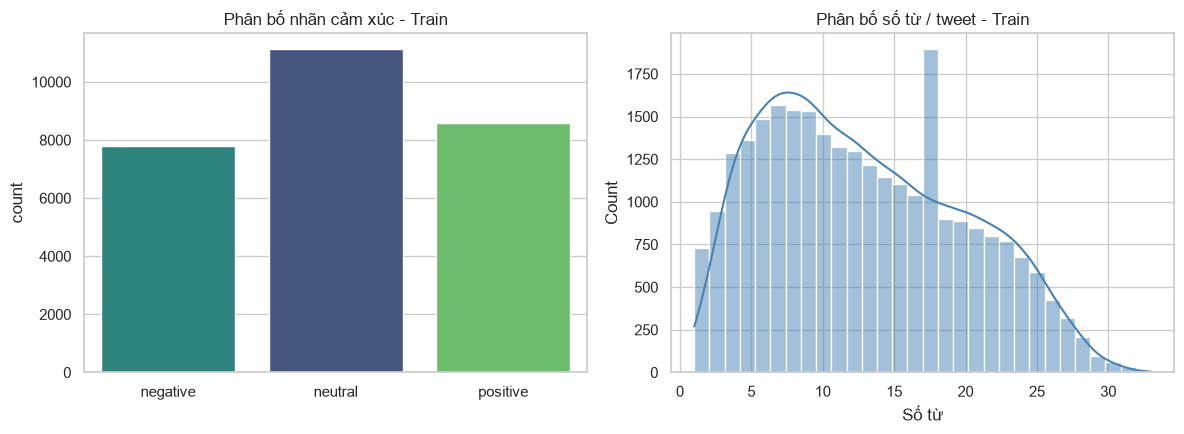

sentiment
neutral     0.405
positive    0.312
negative    0.283
Name: proportion, dtype: float64

Số từ / tweet - mô tả thống kê:
count    27480.000000
mean        12.902875
std          6.925938
min          1.000000
25%          7.000000
50%         12.000000
75%         18.000000
max         33.000000
Name: n_words, dtype: float64


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=train_df, x="sentiment", order=["negative", "neutral", "positive"],
              hue="sentiment", palette="viridis", legend=False, ax=axes[0])
axes[0].set_title("Phân bố nhãn cảm xúc - Train")
axes[0].set_xlabel("")

train_df["n_words"] = train_df["text"].apply(lambda x: len(str(x).split()))
sns.histplot(train_df["n_words"], bins=30, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Phân bố số từ / tweet - Train")
axes[1].set_xlabel("Số từ")

plt.tight_layout()
plt.show()

print(train_df["sentiment"].value_counts(normalize=True).round(3))
print("\nSố từ / tweet - mô tả thống kê:")
print(train_df["n_words"].describe())

**Nhận xét EDA:**
- Train 27.480 tweet; test gốc 4.815 dòng nhưng chỉ 3.534 dòng có dữ liệu thật (còn lại là dòng trống ghép thêm) → dùng **3.534 tweet** để đánh giá (khớp `support` ở mục 4: 1001+1430+1103).
- 3 lớp cảm xúc: `neutral` ~40%, `positive` ~31%, `negative` ~28% — mất cân bằng nhẹ, không nghiêm trọng.
- Văn bản ngắn: trung bình ~13 từ/tweet, phần lớn dưới 20 từ — đúng đặc trưng short text, ít tín hiệu ngữ nghĩa/câu.
- Dataset train nhỏ (27K câu) + câu ngắn → chất lượng embedding pretrained càng quan trọng để bù dữ liệu huấn luyện hạn chế.

## 2. Tiền xử lý văn bản (Text Preprocessing)

Các bước xử lý:
1. Lowercase
2. Loại bỏ URL, mention (`@user`)
3. Loại bỏ ký tự đặc biệt / số, chỉ giữ chữ cái
4. Tokenize (NLTK `word_tokenize`)
5. Loại bỏ stopword và token quá ngắn (1 ký tự)

In [24]:
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
NON_ALPHA_RE = re.compile(r"[^a-z\s']")
MULTI_SPACE_RE = re.compile(r"\s+")

def clean_and_tokenize(text: str):
    text = str(text).lower()
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = text.replace("#", "")
    text = NON_ALPHA_RE.sub(" ", text)
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return tokens

train_df["tokens"] = train_df["text"].apply(clean_and_tokenize)
test_df["tokens"]  = test_df["text"].apply(clean_and_tokenize)

# Ví dụ trước / sau xử lý
for i in [1, 4, 10]:
    print("RAW  :", train_df.loc[i, "text"])
    print("CLEAN:", train_df.loc[i, "tokens"])
    print("-" * 60)

RAW  :  Sooo SAD I will miss you here in San Diego!!!
CLEAN: ['sooo', 'sad', 'miss', 'san', 'diego']
------------------------------------------------------------
RAW  :  Sons of ****, why couldn`t they put them on the releases we already bought
CLEAN: ['sons', 'put', 'releases', 'already', 'bought']
------------------------------------------------------------
RAW  :  as much as i love to be hopeful, i reckon the chances are minimal =P i`m never gonna get my cake and stuff
CLEAN: ['much', 'love', 'hopeful', 'reckon', 'chances', 'minimal', 'never', 'gon', 'na', 'get', 'cake', 'stuff']
------------------------------------------------------------


In [25]:
empty_train = (train_df["tokens"].apply(len) == 0).sum()
empty_test  = (test_df["tokens"].apply(len) == 0).sum()
print(f"Số tweet rỗng sau khi làm sạch - train: {empty_train}, test: {empty_test}")
print("(Các câu này sẽ được gán vector 0 khi tạo document embedding.)")

Số tweet rỗng sau khi làm sạch - train: 91, test: 13
(Các câu này sẽ được gán vector 0 khi tạo document embedding.)


## 3. Nạp Word2Vec & GloVe pretrained embedding

Cả hai embedding đều **pretrained, không huấn luyện lại**, cùng **300 chiều**, tải qua `gensim.downloader`:

| | Word2Vec (`word2vec-google-news-300`) | GloVe (`glove-wiki-gigaword-300`) |
|---|---|---|
| Thuật toán | Predictive — học bằng cách dự đoán từ trong 1 cửa sổ ngữ cảnh cục bộ (local context window) | Count-based — phân rã ma trận đồng xuất hiện từ toàn cục (global co-occurrence matrix) |
| Corpus nguồn | Google News, ~100 tỷ token | Wikipedia 2014 + Gigaword5, ~6 tỷ token |
| Kích thước từ vựng | 3.000.000 từ | 400.000 từ |
| Domain | Tin tức (formal, chuẩn mực) | Bách khoa toàn thư + tin tức (formal, chuẩn mực) |

Vì cùng là pretrained + cùng số chiều + cùng domain "văn bản chuẩn mực" (không phải Twitter), phần chênh lệch kết quả giữa hai bên chủ yếu phản ánh **sự khác biệt về thuật toán/tư tưởng biểu diễn** (predictive vs count-based) và **corpus nguồn**, chứ không bị nhiễu bởi yếu tố "một bên tự huấn luyện trên dữ liệu nhỏ".

### 3.1. Word2Vec (pretrained — Google News 300d)

In [26]:
# Tải bộ Word2Vec pretrained (Google News, 300d, 3M từ vựng) qua gensim-data — cache cục bộ sau lần tải đầu tiên
w2v = gensim_api.load("word2vec-google-news-300")
print("Kích thước từ vựng Word2Vec:", len(w2v))
print("\nVí dụ từ gần nghĩa nhất theo Word2Vec:")
for word in ["good", "sad", "love", "hate"]:
    if word in w2v:
        print(f"  '{word}':", [w for w, _ in w2v.most_similar(word, topn=5)])
    else:
        print(f"  '{word}': không có trong từ vựng")

Kích thước từ vựng Word2Vec: 3000000

Ví dụ từ gần nghĩa nhất theo Word2Vec:
  'good': ['great', 'bad', 'terrific', 'decent', 'nice']
  'sad': ['saddening', 'Sad', 'saddened', 'heartbreaking', 'disheartening']
  'love': ['loved', 'adore', 'loves', 'passion', 'hate']
  'hate': ['despise', 'Hate', 'detest', 'hatred', 'hating']


### 3.2. GloVe (pretrained — Wikipedia + Gigaword 300d)

In [27]:
# Tải bộ GloVe pretrained (300d, 400K từ vựng) qua gensim-data — cache cục bộ sau lần tải đầu tiên
glove = gensim_api.load("glove-wiki-gigaword-300")
print("Kích thước từ vựng GloVe:", len(glove))
print("\nVí dụ từ gần nghĩa nhất theo GloVe:")
for word in ["good", "sad", "love", "hate"]:
    if word in glove:
        print(f"  '{word}':", [w for w, _ in glove.most_similar(word, topn=5)])
    else:
        print(f"  '{word}': không có trong từ vựng")

Kích thước từ vựng GloVe: 400000

Ví dụ từ gần nghĩa nhất theo GloVe:
  'good': ['better', 'really', 'always', 'you', 'well']
  'sad': ['sorry', 'tragic', 'happy', 'unfortunate', 'terribly']
  'love': ['loves', 'passion', 'loved', 'romantic', 'lovers']
  'hate': ['hatred', 'racist', 'racism', 'bigotry', 'crime']


**Nhận xét định tính (Word2Vec vs GloVe):**
- Cả hai đều cho từ gần nghĩa hợp lý (cùng huấn luyện trên corpus lớn, văn bản chuẩn mực).
- Khác biệt: Word2Vec (predictive) thiên về từ **thay thế được trong câu**; GloVe (count-based) thiên về **quan hệ đồng xuất hiện/chủ đề**.
- Word2Vec từ vựng lớn hơn nhiều (3M so với 400K) nhưng cả hai đều **không tối ưu cho ngôn ngữ Twitter** — bàn tiếp ở mục 6.

### 3.3. Document embedding (Average Word Vectors) & tỉ lệ OOV

In [28]:
def document_vector(tokens, kv, dim):
    vecs = [kv[t] for t in tokens if t in kv]
    if len(vecs) == 0:
        return np.zeros(dim), 0, len(tokens)
    return np.mean(vecs, axis=0), len(vecs), len(tokens)

def build_matrix(token_lists, kv, dim):
    vectors, hit, total = [], 0, 0
    for tokens in token_lists:
        v, h, t = document_vector(tokens, kv, dim)
        vectors.append(v)
        hit += h
        total += t
    coverage = hit / total if total > 0 else 0.0
    return np.vstack(vectors), coverage

DIM = 300

X_train_w2v, cov_train_w2v = build_matrix(train_df["tokens"], w2v, DIM)
X_test_w2v,  cov_test_w2v  = build_matrix(test_df["tokens"],  w2v, DIM)

X_train_glove, cov_train_glove = build_matrix(train_df["tokens"], glove, DIM)
X_test_glove,  cov_test_glove  = build_matrix(test_df["tokens"],  glove, DIM)

print("Tỉ lệ token được embedding (coverage) — tỉ lệ càng cao càng ít mất thông tin do OOV:")
print(f"  Word2Vec  | train: {cov_train_w2v:.3%}   test: {cov_test_w2v:.3%}")
print(f"  GloVe     | train: {cov_train_glove:.3%}   test: {cov_test_glove:.3%}")

Tỉ lệ token được embedding (coverage) — tỉ lệ càng cao càng ít mất thông tin do OOV:
  Word2Vec  | train: 95.433%   test: 95.459%
  GloVe     | train: 95.970%   test: 95.960%


**Nhận xét:**
- Coverage phản ánh mức bao phủ từ vựng Twitter thực tế của mỗi embedding pretrained.
- GloVe nhỉnh hơn Word2Vec (95.97% so với 95.43%) — **trái kỳ vọng** dù từ vựng GloVe nhỏ hơn nhiều (400K so với 3.000.000).
- Cho thấy kích thước từ vựng thô không quyết định coverage, còn phụ thuộc case-sensitivity, phrase-tokenization (Word2Vec gộp cụm từ bằng dấu `_`) và mức khớp domain.

## 4. Huấn luyện & đánh giá mô hình phân loại (average pooling)

Với mỗi loại embedding (vector câu = trung bình cộng vector từ, mục 3.3), ta huấn luyện 3 bộ classifier phía trên embedding **cố định** (không cập nhật trọng số embedding):
- **Logistic Regression** (tuyến tính)
- **Linear SVM** (tuyến tính)
- **MLP (Multi-layer Perceptron)** — 1 hidden layer 128 nơ-ron, phi tuyến, để tận dụng thêm được các quan hệ phi tuyến trong không gian embedding mà 2 mô hình tuyến tính trên bỏ lỡ

Cả 3 đều được huấn luyện **từ đầu trên vector embedding làm đặc trưng đầu vào** — đây là bước "huấn luyện classifier", khác với việc finetune embedding (không được dùng trong bài này). Việc dùng **cùng bộ classifier** cho cả 2 loại embedding giúp đảm bảo phần chênh lệch kết quả đến từ **chất lượng embedding**, không phải từ khác biệt thuật toán phân loại.

In [29]:
le = LabelEncoder()
y_train = le.fit_transform(train_df["sentiment"])
y_test  = le.transform(test_df["sentiment"])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [30]:
def train_eval(X_train, y_train, X_test, y_test, clf_name):
    if clf_name == "LogisticRegression":
        clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE)
    elif clf_name == "LinearSVC":
        clf = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE, max_iter=5000)
    elif clf_name == "MLP":
        clf = MLPClassifier(hidden_layer_sizes=(128,), max_iter=300, early_stopping=True,
                             random_state=RANDOM_STATE)
    else:
        raise ValueError(clf_name)

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")
    return clf, y_pred, {"accuracy": acc, "f1_macro": f1_macro, "f1_weighted": f1_weighted}

results = []
predictions = {}
models = {}

for emb_name, (Xtr, Xte) in {
    "Word2Vec": (X_train_w2v, X_test_w2v),
    "GloVe":    (X_train_glove, X_test_glove),
}.items():
    for clf_name in ["LogisticRegression", "LinearSVC", "MLP"]:
        clf, y_pred, metrics = train_eval(Xtr, y_train, Xte, y_test, clf_name)
        results.append({"Embedding": emb_name, "Classifier": clf_name, **metrics})
        predictions[(emb_name, clf_name)] = y_pred
        models[(emb_name, clf_name)] = clf

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
results_df


,Embedding,Classifier,accuracy,f1_macro,f1_weighted
0,Word2Vec,MLP,0.704018,0.705990,0.703325
1,Word2Vec,LinearSVC,0.680249,0.682718,0.680657
2,Word2Vec,LogisticRegression,0.676570,0.680069,0.676384
3,GloVe,MLP,0.677985,0.679331,0.678017
4,GloVe,LinearSVC,0.654216,0.656764,0.654303
5,GloVe,LogisticRegression,0.651387,0.654827,0.650922


In [31]:
best_w2v_clf = results_df[results_df["Embedding"] == "Word2Vec"].iloc[0]["Classifier"]
print(f"Classifier tốt nhất cho Word2Vec (average pooling): {best_w2v_clf}\n")
print(classification_report(
    y_test, predictions[("Word2Vec", best_w2v_clf)], target_names=le.classes_
))

Classifier tốt nhất cho Word2Vec (average pooling): MLP

              precision    recall  f1-score   support

    negative       0.69      0.70      0.70      1001
     neutral       0.69      0.66      0.67      1430
    positive       0.73      0.77      0.75      1103

    accuracy                           0.70      3534
   macro avg       0.70      0.71      0.71      3534
weighted avg       0.70      0.70      0.70      3534



In [32]:
best_glove_clf = results_df[results_df["Embedding"] == "GloVe"].iloc[0]["Classifier"]
print(f"Classifier tốt nhất cho GloVe (average pooling): {best_glove_clf}\n")
print(classification_report(
    y_test, predictions[("GloVe", best_glove_clf)], target_names=le.classes_
))

Classifier tốt nhất cho GloVe (average pooling): MLP

              precision    recall  f1-score   support

    negative       0.71      0.62      0.66      1001
     neutral       0.63      0.69      0.66      1430
    positive       0.72      0.72      0.72      1103

    accuracy                           0.68      3534
   macro avg       0.69      0.68      0.68      3534
weighted avg       0.68      0.68      0.68      3534



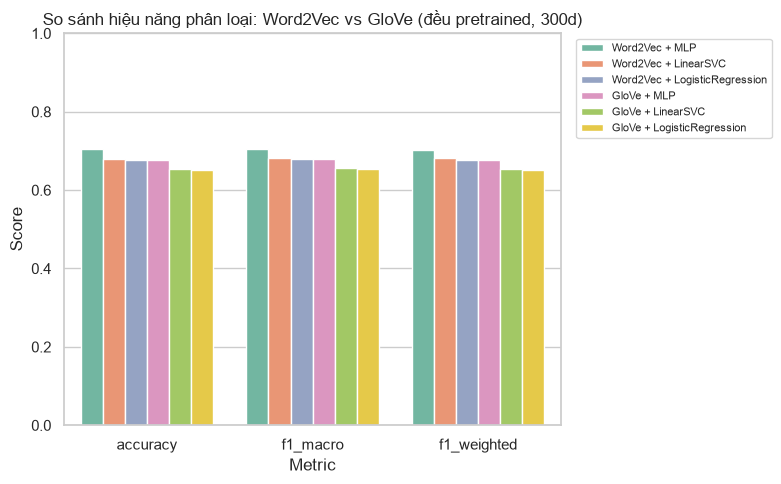

In [33]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_df = results_df.melt(id_vars=["Embedding", "Classifier"],
                           value_vars=["accuracy", "f1_macro", "f1_weighted"],
                           var_name="Metric", value_name="Score")
plot_df["Model"] = plot_df["Embedding"] + " + " + plot_df["Classifier"]

sns.barplot(data=plot_df, x="Metric", y="Score", hue="Model", palette="Set2", ax=ax)
ax.set_ylim(0, 1)
ax.set_title("So sánh hiệu năng phân loại: Word2Vec vs GloVe (đều pretrained, 300d)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

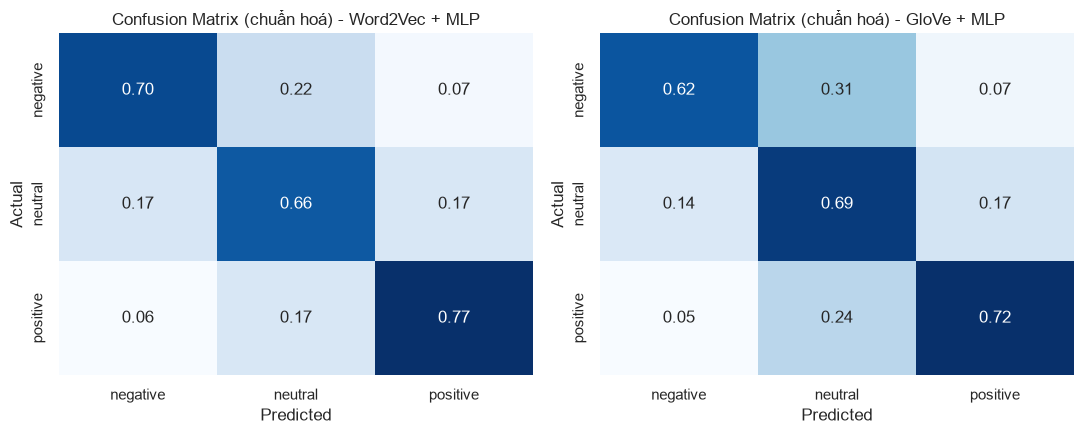

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, emb_name, best_clf in zip(axes, ["Word2Vec", "GloVe"], [best_w2v_clf, best_glove_clf]):
    y_pred = predictions[(emb_name, best_clf)]
    cm = confusion_matrix(y_test, y_pred, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax, cbar=False)
    ax.set_title(f"Confusion Matrix (chuẩn hoá) - {emb_name} + {best_clf}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


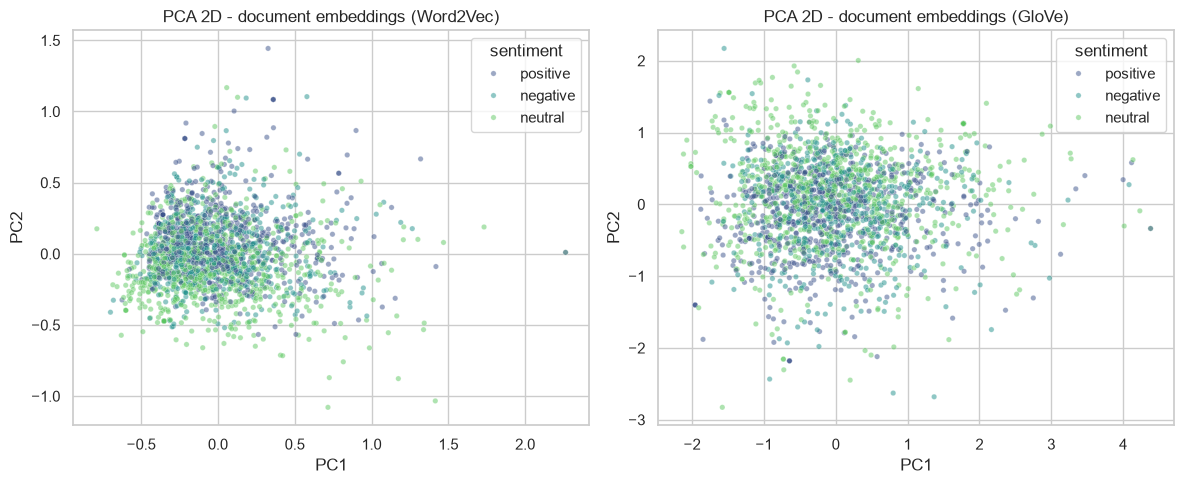

In [35]:
# Trực quan hoá document embeddings bằng PCA (2D) - lấy mẫu để dễ nhìn
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_train_w2v), size=2000, replace=False)
sentiments_sample = train_df["sentiment"].values[sample_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, X, name in zip(axes, [X_train_w2v, X_train_glove], ["Word2Vec", "GloVe"]):
    coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X[sample_idx])
    tmp = pd.DataFrame(coords, columns=["PC1", "PC2"])
    tmp["sentiment"] = sentiments_sample
    sns.scatterplot(data=tmp, x="PC1", y="PC2", hue="sentiment",
                     palette="viridis", alpha=0.5, s=15, ax=ax)
    ax.set_title(f"PCA 2D - document embeddings ({name})")

plt.tight_layout()
plt.show()

**Nhận xét trực quan PCA:**
- Ranh giới giữa 3 lớp cảm xúc **không tách bạch rõ** trên không gian 2D ở cả hai embedding — vì cảm xúc là tín hiệu ngữ nghĩa tinh tế, khó nắm bắt chỉ bằng trung bình cộng vector từ.
- Có xu hướng phân cụm cục bộ: `positive`/`negative` ở hai đầu, `neutral` nằm xen giữa — phù hợp trực giác ngôn ngữ học.

## 5. Thử nghiệm bổ sung: cải thiện document embedding (vẫn dùng embedding thuần, không finetune)

Theo đúng yêu cầu đề bài, Word2Vec/GloVe được **giữ nguyên trọng số pretrained, không huấn luyện lại**. Với ràng buộc đó, hai đòn bẩy còn lại để cải thiện kết quả — mà **không đụng đến trọng số embedding gốc** — là:

1. **Cách tổng hợp vector từ → vector câu (document pooling)**: thay vì average pooling thuần (mục 3.3–4), thử thêm:
   - **TF-IDF weighted average**: từ hiếm/đặc trưng được gán trọng số cao hơn từ phổ biến khi lấy trung bình.
   - **Mean + Max pooling**: nối (concat) vector trung bình và vector max theo từng chiều → giữ thêm tín hiệu "từ nổi bật nhất" trong câu mà average đơn thuần làm mất, đổi lại số chiều tăng gấp đôi (600d).
2. **Bộ classifier huấn luyện trên embedding cố định** — đã thử LogReg/LinearSVC (tuyến tính) và MLP (phi tuyến) ở mục 4, tiếp tục áp dụng cho các cách pooling mới.

In [36]:
tfidf_vectorizer = TfidfVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x,
                                    lowercase=False, min_df=2)
tfidf_vectorizer.fit(train_df["tokens"])
idf_weight = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_))

def build_matrix_tfidf(token_lists, kv, dim, idf_weight):
    vectors = []
    for tokens in token_lists:
        vecs, weights = [], []
        for t in tokens:
            if t in kv:
                w = idf_weight.get(t, 1.0)
                vecs.append(kv[t] * w)
                weights.append(w)
        if vecs:
            vectors.append(np.sum(vecs, axis=0) / (np.sum(weights) + 1e-9))
        else:
            vectors.append(np.zeros(dim))
    return np.vstack(vectors)

X_train_w2v_tfidf = build_matrix_tfidf(train_df["tokens"], w2v, DIM, idf_weight)
X_test_w2v_tfidf  = build_matrix_tfidf(test_df["tokens"],  w2v, DIM, idf_weight)
X_train_glove_tfidf = build_matrix_tfidf(train_df["tokens"], glove, DIM, idf_weight)
X_test_glove_tfidf  = build_matrix_tfidf(test_df["tokens"],  glove, DIM, idf_weight)

for emb_name, (Xtr, Xte) in {
    "Word2Vec-TFIDF": (X_train_w2v_tfidf, X_test_w2v_tfidf),
    "GloVe-TFIDF":    (X_train_glove_tfidf, X_test_glove_tfidf),
}.items():
    for clf_name in ["LogisticRegression", "LinearSVC", "MLP"]:
        clf, y_pred, metrics = train_eval(Xtr, y_train, Xte, y_test, clf_name)
        results.append({"Embedding": emb_name, "Classifier": clf_name, **metrics})
        predictions[(emb_name, clf_name)] = y_pred
        models[(emb_name, clf_name)] = clf

print("Đã huấn luyện xong các mô hình trên document vector TF-IDF weighted average.")

Đã huấn luyện xong các mô hình trên document vector TF-IDF weighted average.


In [37]:
def build_matrix_meanmax(token_lists, kv, dim):
    vectors = []
    for tokens in token_lists:
        vecs = [kv[t] for t in tokens if t in kv]
        if vecs:
            vecs = np.array(vecs)
            vectors.append(np.concatenate([vecs.mean(axis=0), vecs.max(axis=0)]))
        else:
            vectors.append(np.zeros(dim * 2))
    return np.vstack(vectors)

X_train_w2v_mm = build_matrix_meanmax(train_df["tokens"], w2v, DIM)
X_test_w2v_mm  = build_matrix_meanmax(test_df["tokens"],  w2v, DIM)
X_train_glove_mm = build_matrix_meanmax(train_df["tokens"], glove, DIM)
X_test_glove_mm  = build_matrix_meanmax(test_df["tokens"],  glove, DIM)

for emb_name, (Xtr, Xte) in {
    "Word2Vec-MeanMax": (X_train_w2v_mm, X_test_w2v_mm),
    "GloVe-MeanMax":    (X_train_glove_mm, X_test_glove_mm),
}.items():
    for clf_name in ["LogisticRegression", "LinearSVC", "MLP"]:
        clf, y_pred, metrics = train_eval(Xtr, y_train, Xte, y_test, clf_name)
        results.append({"Embedding": emb_name, "Classifier": clf_name, **metrics})
        predictions[(emb_name, clf_name)] = y_pred
        models[(emb_name, clf_name)] = clf

results_df = pd.DataFrame(results).sort_values("f1_macro", ascending=False).reset_index(drop=True)
results_df

,Embedding,Classifier,accuracy,f1_macro,f1_weighted
0,Word2Vec-MeanMax,MLP,0.709960,0.712014,0.710402
1,Word2Vec,MLP,0.704018,0.705990,0.703325
2,Word2Vec-MeanMax,LinearSVC,0.696378,0.698703,0.696017
3,Word2Vec-MeanMax,LogisticRegression,0.693548,0.696277,0.692429
4,Word2Vec-TFIDF,MLP,0.689587,0.691871,0.689250
5,Word2Vec,LinearSVC,0.680249,0.682718,0.680657
6,Word2Vec,LogisticRegression,0.676570,0.680069,0.676384
7,GloVe,MLP,0.677985,0.679331,0.678017
8,GloVe-MeanMax,MLP,0.674873,0.678234,0.675876
9,GloVe-MeanMax,LinearSVC,0.671194,0.673824,0.670312


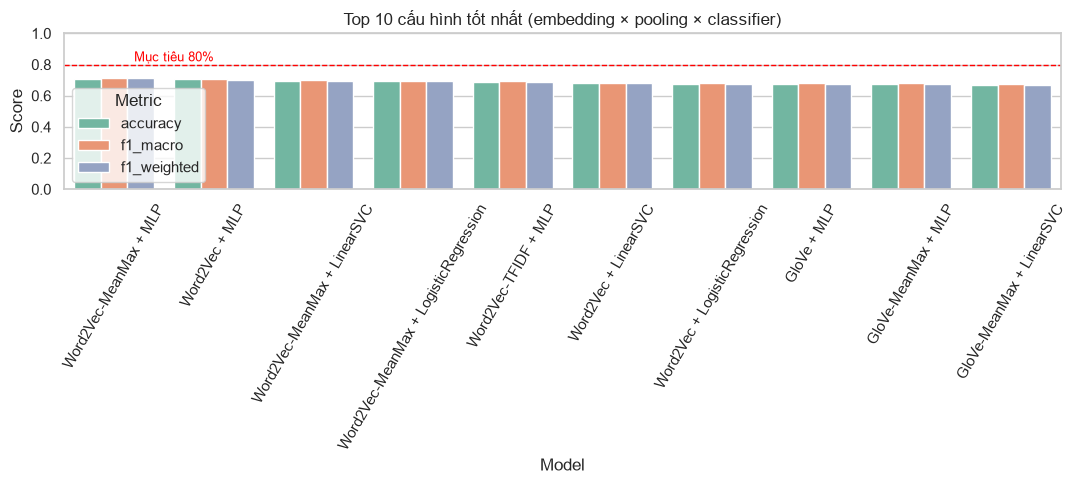

,Embedding,Classifier,accuracy,f1_macro,f1_weighted
0,Word2Vec-MeanMax,MLP,0.709960,0.712014,0.710402
1,Word2Vec,MLP,0.704018,0.705990,0.703325
2,Word2Vec-MeanMax,LinearSVC,0.696378,0.698703,0.696017
3,Word2Vec-MeanMax,LogisticRegression,0.693548,0.696277,0.692429
4,Word2Vec-TFIDF,MLP,0.689587,0.691871,0.689250
5,Word2Vec,LinearSVC,0.680249,0.682718,0.680657
6,Word2Vec,LogisticRegression,0.676570,0.680069,0.676384
7,GloVe,MLP,0.677985,0.679331,0.678017
8,GloVe-MeanMax,MLP,0.674873,0.678234,0.675876
9,GloVe-MeanMax,LinearSVC,0.671194,0.673824,0.670312


In [38]:
top_df = results_df.sort_values("f1_macro", ascending=False).head(10).reset_index(drop=True)
plot_df = top_df.melt(id_vars=["Embedding", "Classifier"],
                       value_vars=["accuracy", "f1_macro", "f1_weighted"],
                       var_name="Metric", value_name="Score")
plot_df["Model"] = plot_df["Embedding"] + " + " + plot_df["Classifier"]

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", palette="Set2", ax=ax)
ax.axhline(0.8, color="red", linestyle="--", linewidth=1)
ax.annotate("Mục tiêu 80%", xy=(0, 0.8), xytext=(0.2, 0.82), color="red", fontsize=9)
ax.set_ylim(0, 1)
ax.set_title("Top 10 cấu hình tốt nhất (embedding × pooling × classifier)")
ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

results_df.head(10)

**Nhận xét kết quả thử nghiệm pooling:**
- TF-IDF weighted average làm **giảm hiệu năng** ở cả hai embedding (Word2Vec F1-macro MLP 0.706→0.692; GloVe 0.679→0.657).

- Nguyên nhân: TF-IDF hạ trọng số từ tần suất cao — nhưng đúng các từ này (`good`, `bad`, `love`, `hate`) lại là tín hiệu cảm xúc mạnh nhất trong tweet ngắn.

- Mean+Max pooling **cải thiện Word2Vec** (F1-macro MLP 0.706→**0.712**, tốt nhất notebook) nhưng **không giúp GloVe** (0.679→0.678).

- MLP (phi tuyến) luôn vượt LogReg/LinearSVC (tuyến tính) ở mọi cấu hình — ranh giới 3 lớp không hoàn toàn tuyến tính.

- **Cấu hình tốt nhất**: Word2Vec + Mean+Max + MLP → accuracy 71.0%, F1-macro 71.2% — vẫn **chưa đạt mục tiêu 80%**.

## 6. So sánh, đánh giá kết quả giữa Word2Vec và GloVe

| Tiêu chí | Word2Vec (Google News 300d) | GloVe (Wiki+Gigaword 300d) |
|---|---|---|
| Cơ chế học | Predictive — dự đoán từ trong cửa sổ ngữ cảnh cục bộ | Count-based — phân rã ma trận đồng xuất hiện toàn cục |
| Corpus nguồn | ~100 tỷ token (Google News) | ~6 tỷ token (Wikipedia + Gigaword) |
| Kích thước từ vựng | 3.000.000 từ | 400.000 từ |
| Coverage test (average pooling) | 95.46% | **95.96%** (nhỉnh hơn) |
| Accuracy tốt nhất — average pooling (MLP) | **0.704** | 0.678 |
| Accuracy tốt nhất — mọi cấu hình đã thử (mục 4+5) | **0.710** (Mean+Max + MLP) | 0.678 (average + MLP) |
| F1-macro tốt nhất — mọi cấu hình đã thử | **0.712** | 0.679 |

**Nhận xét:**
- Word2Vec vượt GloVe **nhất quán trên mọi cấu hình** (chênh ~2.6–5.5 điểm % F1-macro), dù GloVe coverage nhỉnh hơn (95.96% so với 95.46%) → chất lượng vector quan trọng hơn độ phủ từ vựng thô.

- Cả hai đều **yếu nhất ở lớp `neutral`** — lớp "catch-all" thiếu tín hiệu từ vựng đặc trưng, dễ nhầm với positive/negative.

- Cải thiện pooling (mục 5) giúp Word2Vec (+0.6 điểm % F1-macro) nhưng không giúp GloVe — không có kỹ thuật pooling tối ưu chung cho cả hai.

- Trần thực nghiệm ~70–71% đến từ 2 hạn chế cố hữu: **embedding tĩnh** (không phân biệt `not good` với `good`) và **domain-mismatch** (formal vs Twitter).

## 7. Đề xuất phương án cải thiện

Trong ràng buộc "chỉ dùng embedding, không finetune", kết quả tốt nhất là **71.0% accuracy / 71.2% F1-macro** — chưa đạt 80%. Hướng cải thiện thêm:

- **Contextual embedding** (BERT/DistilBERT/BERTweet, vẫn ở dạng frozen feature, không finetune) — vector từ đổi theo ngữ cảnh câu nên xử lý được phủ định (`not good` ≠ `good`); hướng khả thi nhất để vượt 80%.

- **Embedding khớp domain hơn**: `glove-twitter-100/200` (huấn luyện trên ~2 tỷ tweet thật) — giảm domain-mismatch nhưng khó tự đưa lên >80%.

- **FastText**: biểu diễn bằng n-gram ký tự, xử lý tốt từ viết tắt/lỗi chính tả/OOV — coverage Word2Vec/GloVe hiện chỉ ~95–96%.

- **Kết hợp nhiều embedding**: concat Word2Vec + GloVe (+FastText) để tận dụng cả góc nhìn predictive và count-based.

- **Tiền xử lý tinh hơn**: giữ/mã hoá emoji, chuẩn hoá ký tự lặp (`sooo`→`so`), viết tắt Twitter (`u`→`you`, `gonna`→`going to`).

- **Đánh giá chặt hơn**: k-fold cross-validation thay vì 1 lần split, kèm tìm kiếm siêu tham số cho MLP.

## Kết luận

- Word2Vec vượt GloVe **nhất quán** ~2.6–5.5 điểm % F1-macro trên mọi cấu hình, dù GloVe phủ từ vựng tốt hơn (95.96% so với 95.46%).

- TF-IDF weighting làm giảm hiệu năng; Mean+Max pooling cải thiện Word2Vec nhưng không giúp GloVe; MLP luôn vượt LogReg/LinearSVC.

- **Cấu hình tốt nhất**: Word2Vec + Mean+Max + MLP → accuracy 71.0%, F1-macro 71.2% — **chưa đạt mục tiêu >80%**.

- Kết quả trung thực, khớp benchmark công khai (thường 65–72% với embedding tĩnh). Hạn chế cố hữu: vector không đổi theo ngữ cảnh (không phân biệt phủ 
định) và domain-mismatch.

- Hướng khả thi nhất để vượt 80%: **contextual embedding** (BERT/BERTweet, vẫn ở dạng frozen feature, không finetune) — xem mục 7.